---
title: Dataset Explorations
date: 09/2025
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

In [83]:
# package imports
from artools.loading_utils import load_ais, load_cell_areas
from artools.attribute_utils import find_region_masks, find_landfalling_region, extract_trajectory, add_start_date, add_end_date
import xarray as xr
from matplotlib.cm import Set3
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
import matplotlib.path as mpath
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import seaborn as sns
from scipy import stats
import numpy as np

In [31]:
# load up input products
ais_mask = load_ais('../input_data/antarctic_masks/')
cell_areas = load_cell_areas('../input_data/area/')

In [40]:
# load up catalog
full_catalog = pd.read_hdf('../catalogs/official/epsspace0.5_epstime12_minpts5_nreppts10_seed12345.h5')
landfalling_catalog = full_catalog[full_catalog.is_landfalling]

We add several features to the catalog, including landfalling region, trajectories of ARs, start dates, and end dates

In [47]:
# add features to catalog

region_defs = {'MBL': [-150, -120], 
               'ELS': [-120, -75],
               'AP': [-75, -50],
               'FRIS': [-50, -30],
               'QML': [-30, 30],
               'END': [30, 75],
               'QMC': [75, 120],
               'WLK': [120, 150],
               'VICT': [150, 180],
               'RIS': [-180, -150]}
region_defs_coarser = {'West': [-150, -30], 
               'East 1': [-30, 75],
               'East 2': [75, -150]}
region_masks = find_region_masks(region_defs, ais_mask)
region_masks_coarser = find_region_masks(region_defs_coarser, ais_mask)

landfalling_catalog['coarser_region'] = landfalling_catalog['data_array'].apply(lambda x: 
                                                                                find_landfalling_region(x, cell_areas, region_masks_coarser))
landfalling_catalog['finer_region'] = landfalling_catalog['data_array'].apply(lambda x: 
                                                                                find_landfalling_region(x, cell_areas, region_masks))
landfalling_catalog['trajectory'] = landfalling_catalog['data_array'].apply(extract_trajectory)

In [58]:
landfalling_catalog['start_date'] = landfalling_catalog['data_array'].apply(lambda x:
                                                                           add_start_date(x, ais_mask))
landfalling_catalog['end_date'] = landfalling_catalog['data_array'].apply(lambda x:
                                                                           add_start_date(x, ais_mask))

In [59]:
region_areas = {}

for region, mask in region_masks_coarser.items():
    region_areas[region] = mask.dot(cell_areas).values/(10**6)

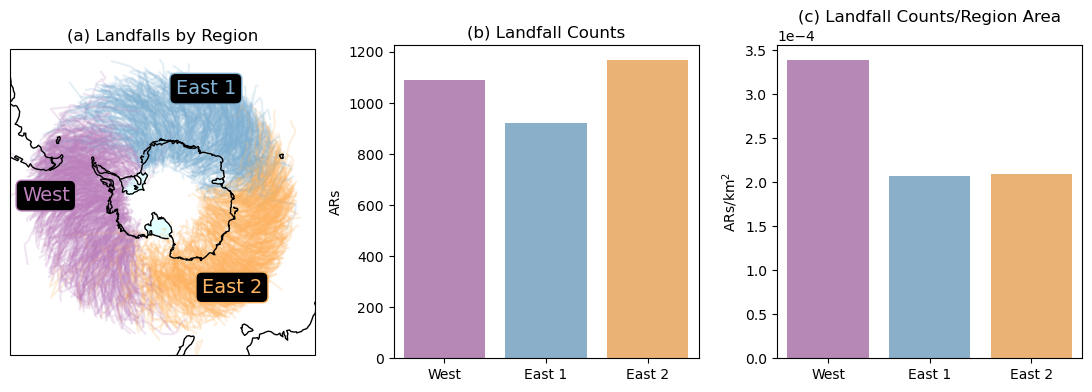

In [60]:
color_mapping_coarser = {'East 1': Set3(4), 'East 2': Set3(5), 'West': Set3(9)}

fig = plt.figure(figsize=(11,4))
ax1 = plt.subplot(131, projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.))

notables = ['2022_9', '2022_12']

for index, row in landfalling_catalog.iterrows():
    trajectory = row.trajectory

    if index in notables:
        ax1.plot(trajectory.avg_lon, trajectory.avg_lat, transform=ccrs.Geodetic(), color='red', alpha=1)
    else:
        ax1.plot(trajectory.avg_lon, trajectory.avg_lat, transform=ccrs.Geodetic(), color=color_mapping_coarser[row.coarser_region], alpha=0.2)

for label in region_defs_coarser.keys():
    if label == 'East 2':
        ax1.text((region_defs_coarser[label][0] + region_defs_coarser[label][1])/2 + 180, -53, label, fontsize=14, horizontalalignment='center', bbox=dict(facecolor='black', edgecolor=color_mapping_coarser[label], boxstyle='round'), transform=ccrs.PlateCarree(), color=color_mapping_coarser[label], zorder=40)
    else:
        ax1.text((region_defs_coarser[label][0] + region_defs_coarser[label][1])/2, -53, label, fontsize=14, horizontalalignment='center', bbox=dict(facecolor='black', edgecolor=color_mapping_coarser[label], boxstyle='round'), transform=ccrs.PlateCarree(), color=color_mapping_coarser[label], zorder=40)



ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
ax1.add_feature(ice_shelf_poly,linewidth=3)
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
ax1.add_feature(ice_shelf_line,linewidth=1,zorder=13)
ax1.coastlines(resolution='110m',linewidth=1,zorder=32)
ax1.set_extent([-180,180,-90,-42], ccrs.PlateCarree())
ax1.set_title('(a) Landfalls by Region')
ax1.grid(True, linestyle='--', color='gray', alpha=0.5)

    
# Map extent 
#ax.gridlines(alpha=0.5, zorder=33)
#fig.savefig(str(home_dir) + '/plots/paper_plots/regional_trajectory_map.png', dpi=100)
ax2 = plt.subplot(132)
sns.countplot(landfalling_catalog, x='coarser_region', ax=ax2, order=['West', 'East 1', 'East 2'], hue='coarser_region', palette=color_mapping_coarser)
ax2.set_title('(b) Landfall Counts')
ax2.set_ylabel('ARs')
ax2.set_xlabel('')

ax3 = plt.subplot(133)
region_df = landfalling_catalog.groupby('coarser_region').size()
region_df = pd.concat([region_df.rename('count'), pd.Series(region_areas).rename('area')], axis=1, names=['coarser_region', 'area'])
region_df['storms_per_area'] = region_df['count']/region_df['area']
sns.barplot(data=region_df, x=region_df.index, y='storms_per_area', ax=ax3, order=['West', 'East 1', 'East 2'], hue=region_df.index, palette=color_mapping_coarser)
ax3.set_title('(c) Landfall Counts/Region Area')
ax3.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax3.set_ylabel(r'ARs/km$^2$')
ax3.set_xlabel('')

fig.tight_layout(pad=1)
fig.savefig('../output/regional_counts.png', dpi=100)

In [72]:
years = landfalling_catalog.start_date.dt.year
landfalling_catalog['landfalling_year'] = years
year_df = landfalling_catalog.groupby('landfalling_year', as_index=False).size()

In [73]:
year_df['size'].describe()

count     43.000000
mean      73.930233
std       10.718021
min       48.000000
25%       69.000000
50%       73.000000
75%       80.000000
max      101.000000
Name: size, dtype: float64

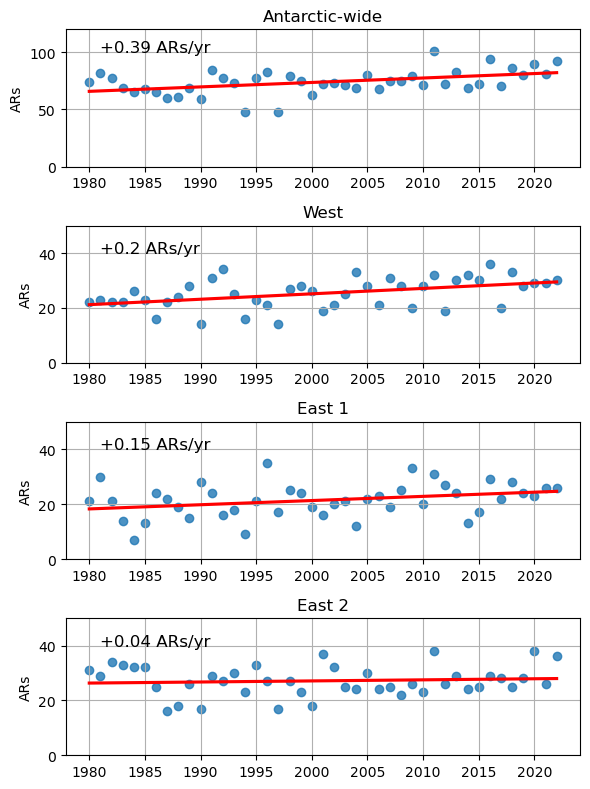

In [74]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(6,8))

cur_ax = axs[0]

sns.regplot(data=year_df, x='landfalling_year', y='size', ci=None, line_kws={"color": "red"}, ax=cur_ax)
ar_rate = round(stats.linregress(year_df.landfalling_year, year_df['size'])[0], 2)
text = f'+{ar_rate} ARs/yr'
cur_ax.set_title('Antarctic-wide')
cur_ax.set_ylim([0, 120])
cur_ax.set_xticks(np.arange(1980, 2021, 5))
cur_ax.text(1981, 100, s=text, fontsize=12)
cur_ax.set_xlabel('')
cur_ax.set_ylabel('ARs')
cur_ax.grid(True)

year_df = landfalling_catalog.groupby(['landfalling_year', 'coarser_region'], as_index=False).size()

coord = 1
for label in region_masks_coarser.keys():
    cur_ax =axs[coord%4]

    year_region_df = year_df[year_df.coarser_region == label]
    sns.regplot(data=year_region_df, x='landfalling_year', y='size', ci=None, line_kws={"color": "red"}, ax=cur_ax)
    ar_rate = round(stats.linregress(year_region_df.landfalling_year, year_region_df['size'])[0], 2)
    text = f'+{ar_rate} ARs/yr'
    cur_ax.set_title(label)
    cur_ax.set_ylim([0, 50])
    cur_ax.set_xticks(np.arange(1980, 2021, 5))
    cur_ax.text(1981, 40, s=text, fontsize=12)
    cur_ax.set_xlabel('')
    cur_ax.set_ylabel('ARs')
    cur_ax.grid(True)

    coord += 1

fig.tight_layout()

fig.savefig('../output/regional_count_trends.png', dpi=100)

In [75]:
year_df.groupby('coarser_region')['size'].describe()

,count,mean,std,min,25%,50%,75%,max
coarser_region,,,,,,,,
East 1,43.0,21.465116,6.146423,7.0,17.5,22.0,25.0,35.0
East 2,43.0,27.139535,5.514403,16.0,24.0,27.0,30.5,38.0
West,43.0,25.325581,5.532247,14.0,21.5,26.0,29.5,36.0
